In [3]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [4]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%cd ../clean_code/

/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


In [4]:
!python main.py --test

Using raw vectors without normalization for distance calculations.
Read 5000 vectors
Estimated max pairwise distance squared, FAISS) = 16295346.0000
 Estimated minimum distance squared = 89648.0000
10 vectors in index after adding initial centroid
Read 6000 vectors
number of centroids: 282, max_centroids: 1000
Read 7000 vectors
number of centroids: 426, max_centroids: 1000
Read 8000 vectors
number of centroids: 566, max_centroids: 1000
Read 9000 vectors
number of centroids: 736, max_centroids: 1000
Read 10000 vectors
number of centroids: 851, max_centroids: 1000
Read 11000 vectors
number of centroids: 976, max_centroids: 1000
Read 12000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 70000 vectorsmean d2= 1545482.9181988034= 2119389.25375mean d2= 2008939.3115833334mean d2= 1924183.5383125mean d2= 1884843.4565mean d2= 1838190.2814583334mean d2= 1813307.6081785713mean d2= 1786350.3585mean d2= 1764673.304236111mean d2= 1754725.5503125m

In [5]:
!python select_landmarks_MI.py --test

Using raw vectors without normalization for distance calculations.
Data loaded from ../../Voltage_Temp/Results/voltage_map.npy
Adding landmark index=0 lm_index=37 with MI=0.6535
Adding landmark index=2 lm_index=508 with MI=1.1680
Adding landmark index=5 lm_index=824 with MI=1.6589
Adding landmark index=3 lm_index=371 with MI=2.1258
Adding landmark index=5 lm_index=881 with MI=2.6132
Adding landmark index=9 lm_index=800 with MI=2.9668
Adding landmark index=19 lm_index=762 with MI=3.4060
Adding landmark index=27 lm_index=705 with MI=3.8395
Adding landmark index=10 lm_index=102 with MI=4.1224
Adding landmark index=11 lm_index=57 with MI=4.3027
added voltage_map to ../../Voltage_Temp/Results/voltage_map.npy


In [2]:
%pwd

'/Users/yoavfreund/projects/VoltageDimentionalReduction/notebooks'

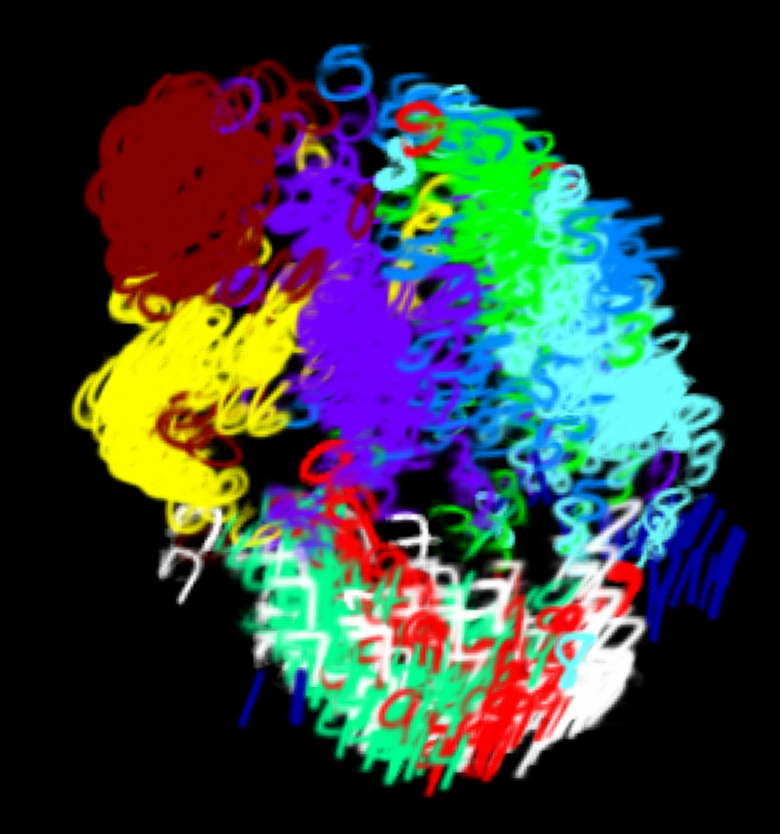

In [ ]:

#load data from the pickle file
with open('../../Voltage_Temp/Results/saved_data.pkl', 'rb') as f:
    data= pickle.load(f)

voltages= data['voltage_map']
centroids= data['centroids']
labels= data['majority_labels']
data=centroids
#plott_mnist_digits(voltages, centroids, majority_labels)
#def plot_mnist_digits(voltages, data, labels, 
transformation="mds"; landmarkSize=3; alpha_actual=1; percent_size=0.02; out_file=None; log_transform=True
"""
Visualizes MNIST digits in 2D space using voltage-based embeddings reduced by PCA or MDS.

Each point in the embedding is rendered as a translucent RGB digit image colored by its label.
Landmark points (voltage = 1) are optionally scaled up to highlight their influence.

Args:
	voltages (VoltageMap): The VoltageMap containing voltages per landmark for each point.
	data (SetOfPoints): The list or array of raw MNIST digit images (each image flattened to length 784).
	labels (List[int]): The ground truth labels for each point (0–9). Used for coloring.
	transformation (str): Dimensionality reduction method: "pca" or "mds" (default: "mds").
	landmarkSize (float): Scaling factor for landmark digits (default: 3).
	alpha_actual (float): Opacity of digit images (0.0 to 1.0, default: 1).
	percent_size (float): Relative size of digit images as a fraction of plot range (default: 0.02).
	out_file (Optional[str]): If provided, saves the output figure to this file path.
	log_transform (bool): If True (default), applies a log transform to the voltage values before visualization.
"""

points = voltages.voltage_array()
if log_transform:
	points = -np.log(points)	

transformed_points = visualHelpers.transform(points, transformation)

fig, ax = plt.subplots(figsize=(12, 10))

# Assign distinct colors for each digit
colors = visualHelpers.get_distinct_colors(len(set(labels)))

x_bound = (transformed_points[:, 0].min(), transformed_points[:, 0].max())
y_bound = (transformed_points[:, 1].min(), transformed_points[:, 1].max())

image_size = (x_bound[1] + y_bound[1] - x_bound[0] - y_bound[0]) * percent_size / 2

for i in range(transformed_points.shape[0]):
	alpha_mask = np.clip(data[i].reshape(28, 28), 0, 255) / 255

	point_voltages = points[i]

	label = labels[i]

	if (label != None):
		color = np.array(colors[int(label)])
		
		size = 1
		print('max voltage:', np.max(point_voltages))
		if (np.max(point_voltages) >0.99):
			size = 3

		# Create RGBA image
		rgb_image = np.zeros((28, 28, 4))

		for c in range(3):
			rgb_image[..., c] = color[c]
		rgb_image[..., 3] = alpha_mask * alpha_actual  # Alpha from pixel intensity

		x, y = transformed_points[i]
		ax.imshow(rgb_image, extent=(x - image_size * size, x + image_size * size, y - image_size * size, y + image_size * size), origin='upper')

ax.set_xlim(x_bound[0] - image_size * landmarkSize, x_bound[1] + image_size * landmarkSize)
ax.set_ylim(y_bound[0] - image_size * landmarkSize, y_bound[1] + image_size * landmarkSize)
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
plt.title("Visualization of Digits")

visualHelpers.standard_save_display(out_file)